# Supervised Learning - Regression
## Agenda
- Regression
- Types of Regression
  - Linear Regression
    - Simple Linear Regression
        - Train Test Split
    - Multiple Linear Regression
        - Overfitting and Underfitting
  - Non Linear Regression
     - Polynomial Regression
- Model Evaluation and Validation
  - Cross Validation Techniques
  - Performanace Metrics
    - Mean Squared Error (MSE)
    - Root Mean Squared Error (RMSE)
    - Mean Absolute Error(MAE)
    - R-Squared (r2 Score)
- Regularization Techniques
  - Lasso Regression
  - Ridge Regression
- Hyperparameter Tuning
  - GridSearchCV
  - RandomSearchCV
- Pipelining in scikit-learn
  

## Regression

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_04/Linear.png)

## Applications of Regression

1. Oil and Gas Industry: Various types of data are collected in the oil and gas industry from the surface and subsurface to understand production and sale processes. Linear and non-linear regression models forecast global oil production.
2. Marketing: In marketing, linear regression helps analyze the effectiveness of advertising campaigns, predict sales based on marketing spend, and segment customers based on demographic data.
3. Retail: Linear regression is utilized in retail for demand forecasting, inventory management, pricing optimization, and customer analytics.
4. Healthcare: Linear regression is applied in healthcare for predicting patient outcomes, analyzing the relationship between medical variables and disease progression, and planning healthcare resources.
5. Real Estate: In the real estate industry, linear regression predicts property prices based on factors such as location, size, amenities, and economic indicators.


## Types Of Regression

Regression types can be classified into two categories: linear and non-linear.

**Linear Regression**

Definition: Linear regression finds a straight-line relationship between the dependent variable and one or more independent variables.

**Non-Linear Regression**

Definition: Non-linear regression finds a relationship between the dependent variable and independent variables using a curve or a more complex shape.


## Linear Regression


**Linear Regression** refers to a supervised learning algorithm used to predict a continuous target variable by modeling its relationship with one or more independent variables through a linear equation.
- It predicts a continuous dependent variable based on one or more independent variables.
- It uses the least squares criterion to estimate the coefficients of the regression equation..
- It can be applied only if there is a linear relationship between the variables.

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_04/Linear.png)

In this case, the dependent variable is continuous, and the independent variables can be either continuous or discrete.


The relationship between a dependent variable (y) and one or more independent variables (x) is established using a best-fit straight line, also known as the regression line.

There are two types of linear regression:
- Simple linear regression
- Multiple linear regression

### __Simple Linear Regression__ 
**Simple Linear Regression**

Definition: Simple linear regression models the relationship between one independent variable and the dependent variable as a straight line.
The equation for Simple Linear Regression is:
 $$ \hat{y} = \beta_0 + \beta_1x $$
where:
- $\hat{y}$ is the dependent variable
- $x$ is the independent variable
- $β_0$ is the intercept
- $β_1$ is the slope


### __Multiple Linear Regression__ ###
**Multiple Linear Regression**
Definition: Multiple linear regression models the relationship between two or more independent variables/predictors/features and the dependent variable as a straight line.
The equation for Multiple Linear Regression:
 $$ \hat{y_i} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \ldots + \beta_px_ p $$
 or
 $$ \hat{y_i} = \beta_0 + \sum_{j=1}^{p} \beta_j.x_{ij} $$
- $ x_1, x_2, \ldots, x_n $ are the predictor variables,
- $ \beta_1, \beta_2, \ldots, \beta_p $ are the coefficients for each predictor.

In [1]:
## Let us see how to fit the linear Regresscion model on a dataset

In [2]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## Read the dataset
df =  pd.read_csv('tvmarketing.csv')
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [4]:
## General Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [5]:
## Statistical Summary
df.describe()

,TV,Sales
count,200.000000,200.000000
mean,147.042500,14.022500
std,85.854236,5.217457
min,0.700000,1.600000
25%,74.375000,10.375000
50%,149.750000,12.900000
75%,218.825000,17.400000
max,296.400000,27.000000


In [6]:
## Missing Value Check

df.isnull().sum()

TV       0
Sales    0
dtype: int64

In [7]:
## Seperate Features as DataFrame and Target as Series

X =  df.iloc[:, :-1]  ## Extracted Features
y =  df.iloc[:, -1]  ## Extracted Target(which is the Last Column

### Perform Train Test Split

Train-test split is a technique in machine learning used to evaluate a model's performance by dividing the data into two parts: a training set and a test set. The model is trained on the training set, learning patterns and parameters, and then evaluated on the test set to see how well it generalizes to new, unseen data.

**Note:** This train-test data split will be used for other implementations as well.

In [8]:
## Install scikit-learn

#!pip install scikit-learn

In [9]:
# Import train_test_split from sklearn model_selection module
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size =  0.3, random_state = 42) 

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(140, 1)
(60, 1)
(140,)
(60,)


In [21]:
## Let us try to see if linear regression works on this data
## Import LinearRegression class from sklearn.linear_model module
## Instantiate the class
### Train the model

In [22]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [24]:
## Train the model

lin_reg.fit(X_train, y_train)

LinearRegression()

In [25]:
## Display Coefficient of Regression and Intercept Values

print(f'Coefficient of Regression  is {lin_reg.coef_}')
print(f'Intercept is {lin_reg.intercept_}')

Coefficient of Regression  is [0.0464078]
Intercept is 7.23945983075114


The Equation of prediction line can be written as `Sales_predicted = 0.0464078 * TV + 7.23945983075114`

In [28]:
## Lets find out model prediction on train data and test data

y_train_pred =  lin_reg.predict(X_train)
y_test_pred =  lin_reg.predict(X_test)

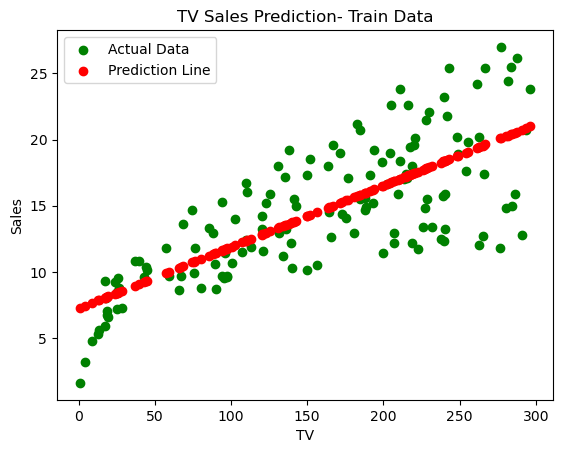

In [32]:
## Visuaize the results

plt.scatter(X_train, y_train, color = 'green', label = 'Actual Data')
plt.scatter(X_train, y_train_pred, color =  'red', label = 'Prediction Line')
plt.legend()
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV Sales Prediction- Train Data')
plt.show()

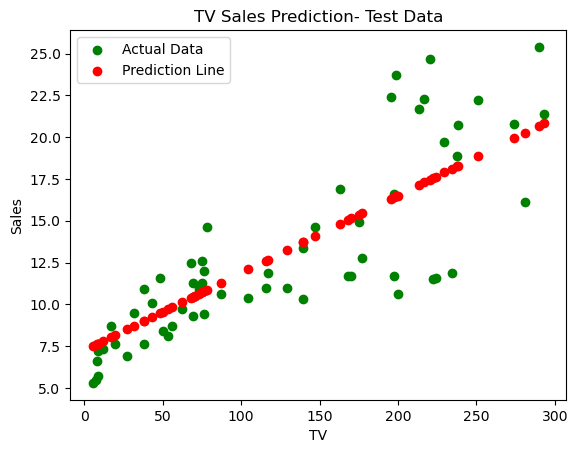

In [33]:
## Visuaize the results

plt.scatter(X_test, y_test, color = 'green', label = 'Actual Data')
plt.scatter(X_test, y_test_pred, color =  'red', label = 'Prediction Line')
plt.legend()
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV Sales Prediction- Test Data')
plt.show()